In [ ]:
from pathlib import Path

import pandas as pd

sources = [
    "output/tpch_optim2.csv",
    "output/ceb_optim2.csv",
    "output/umbra_bench.csv",
    "output/umbra_bench2.csv",
]

# load sources
# if benchmark field is missing: infer from filename (e.g. "tpch_optim2.csv" -> "tpch")
# merge all together in a single dataframe
frames = []
for source in sources:
    frame = pd.read_csv(source)

    if "benchmark" not in frame.columns:
        inferred_benchmark = Path(source).stem.split("_")[0].lower()
        frame["benchmark"] = inferred_benchmark

    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
df.head()

,query_id,scale_factor,system,time_ms,hostname,snapshot,benchmark
0,1,1.0,Bespoke,25.000000,fn02,0f4fe425b8ad2d5631c2497dc81ef5de041aab36,tpch
1,1,1.0,DuckDB,255.584700,fn02,0f4fe425b8ad2d5631c2497dc81ef5de041aab36,tpch
2,2,1.0,Bespoke,5.000000,fn02,0f4fe425b8ad2d5631c2497dc81ef5de041aab36,tpch
3,2,1.0,DuckDB,19.087461,fn02,0f4fe425b8ad2d5631c2497dc81ef5de041aab36,tpch
4,3,1.0,Bespoke,9.000000,fn02,0f4fe425b8ad2d5631c2497dc81ef5de041aab36,tpch


In [25]:
import matplotlib.pyplot as plt


def _apply_journal_rcparams() -> None:
    plt.rcParams["figure.dpi"] = 300
    plt.rcParams["font.size"] = 11
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["axes.linewidth"] = 1.2
    plt.rcParams["xtick.major.width"] = 1.2
    plt.rcParams["ytick.major.width"] = 1.2
    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.2


def _style_ax(ax) -> None:
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)

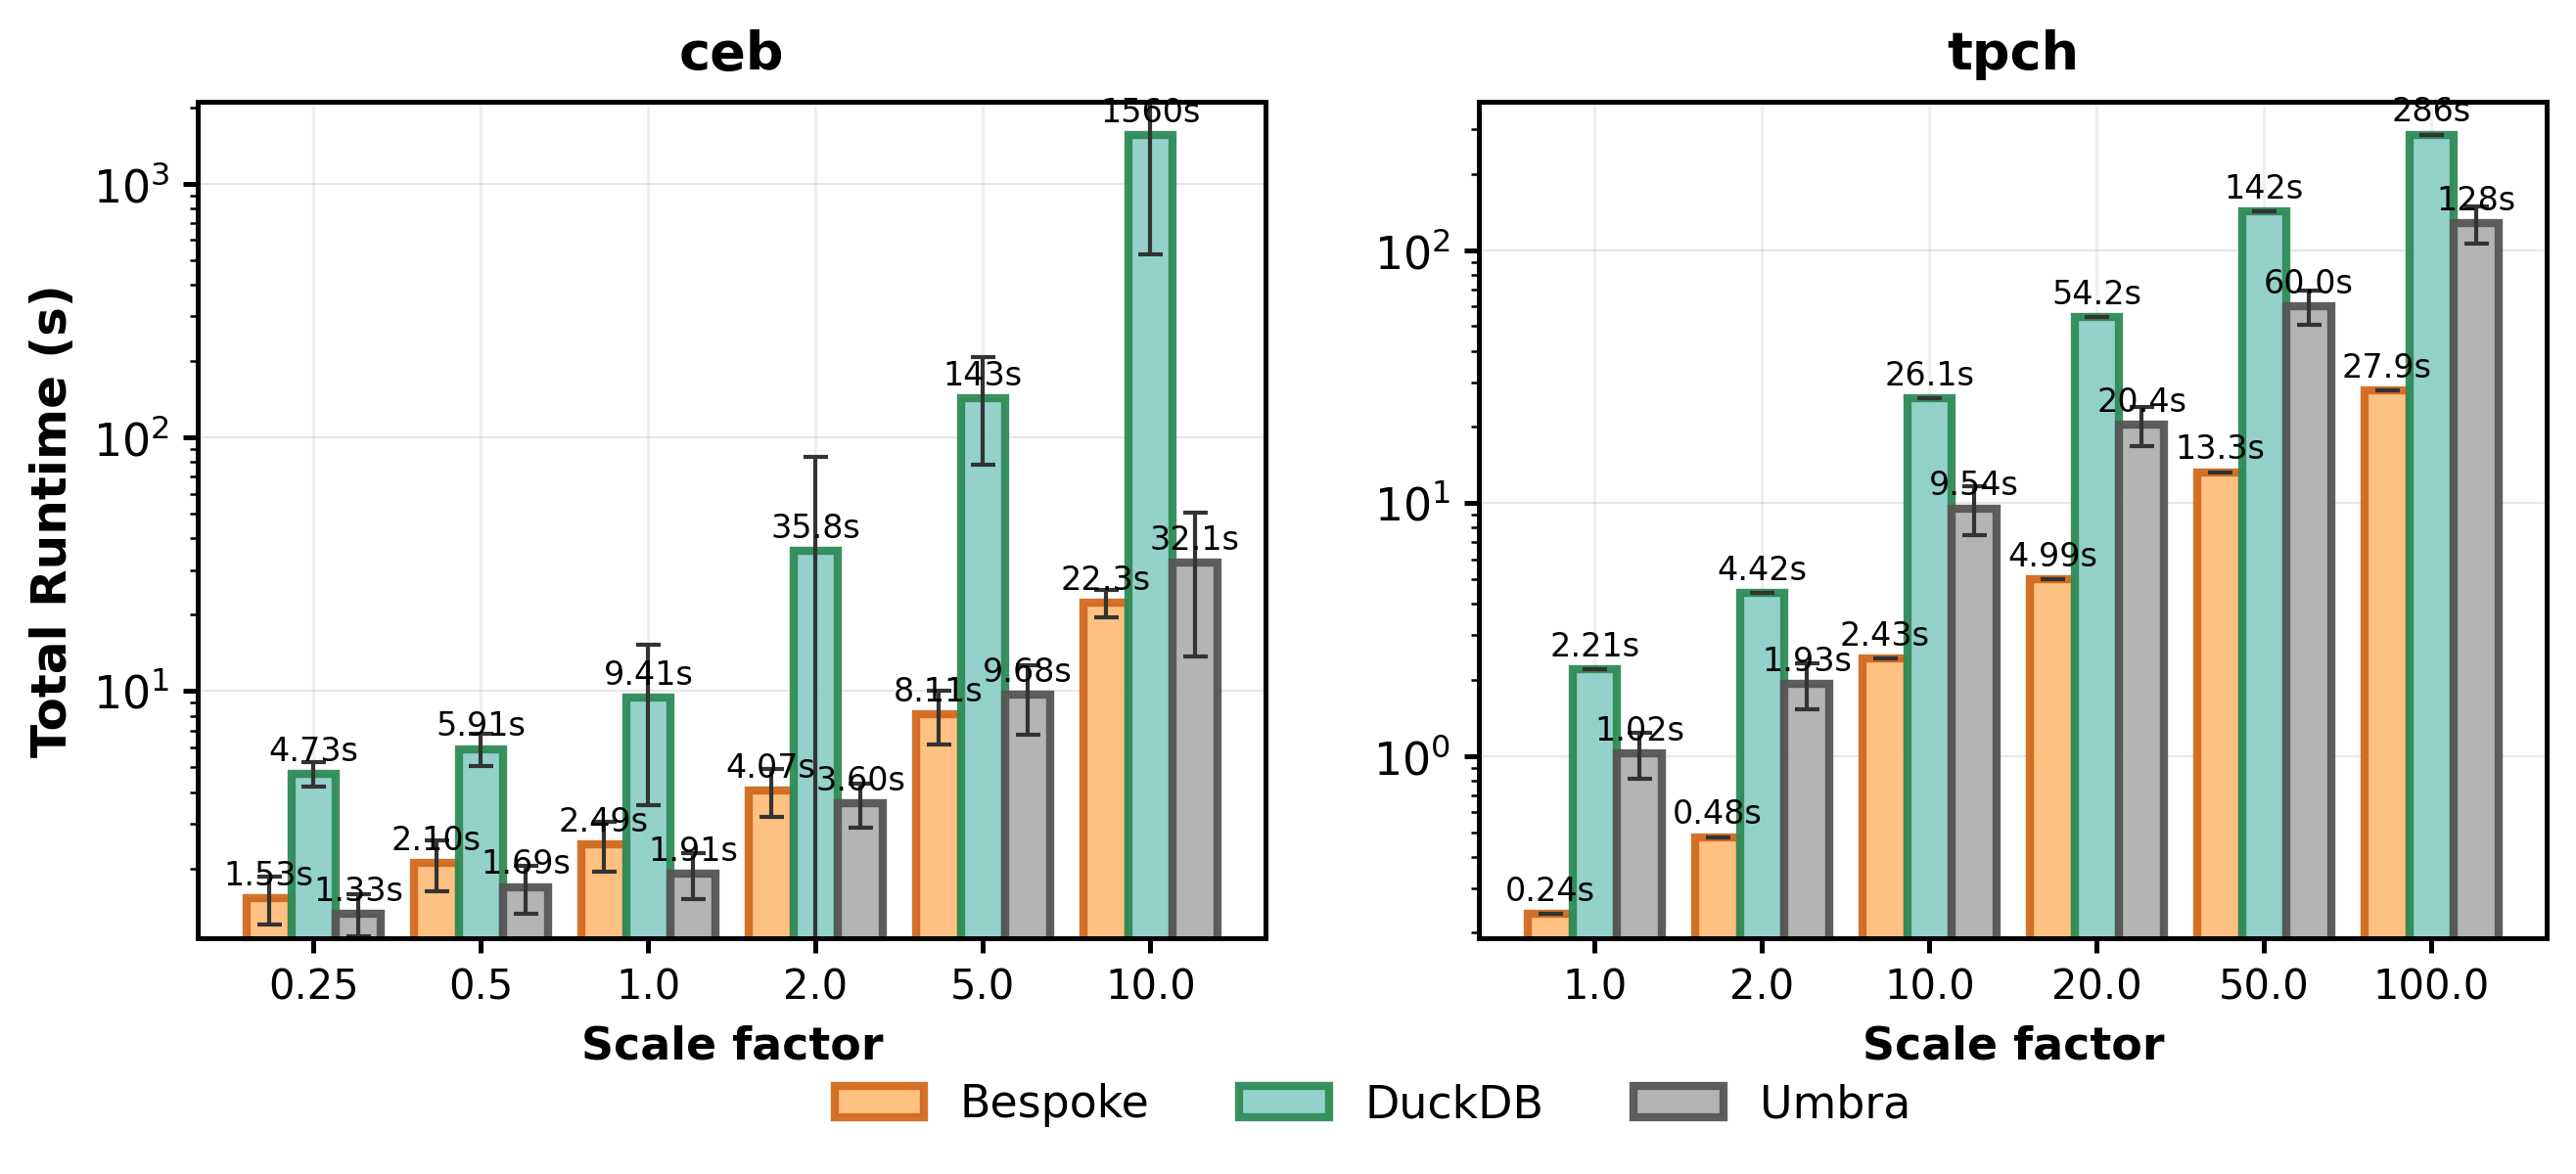

In [ ]:
import numpy as np

_SYSTEM_STYLE = {
    "DuckDB": {"color": "#8ECFC9", "edge": "#2E8B57"},
    "Bespoke": {"color": "#FFBE7A", "edge": "#D2691E"},
}


def _stats(values):
    if not values:
        return 0.0, 0.0
    arr = np.array(values, dtype=float)
    return float(arr.mean()), float(arr.std(ddof=0))


def _to_sf_number(value: str):
    try:
        if "." in value:
            return float(value)
        return int(value)
    except ValueError:
        return value


def _format_runtime_label(value: float, unit: str) -> str:
    if value >= 100:
        return f"{value:.0f}{unit}"
    if value >= 10:
        return f"{value:.1f}{unit}"
    return f"{value:.2f}{unit}"


def collect_scale_factor_totals_from_df(
    data: pd.DataFrame,
    benchmark: str | None = None,
    hostnames: list[str] | None = None,
    exclude_query_ids: tuple[str, ...] = ("8a",),
    ignore_first_n: int = 0,
) -> dict:
    required = {"scale_factor", "query_id", "system", "time_ms"}
    missing = sorted(required - set(data.columns))
    if missing:
        raise ValueError(f"Dataframe is missing required columns: {missing}")

    frame = data.copy()

    if benchmark is not None and "benchmark" in frame.columns:
        frame = frame[frame["benchmark"].astype(str) == str(benchmark)]

    if hostnames and "hostname" in frame.columns:
        host_set = set(hostnames)
        frame = frame[frame["hostname"].astype(str).isin(host_set)]

    if exclude_query_ids:
        frame = frame[~frame["query_id"].astype(str).isin(set(exclude_query_ids))]

    frame["scale_factor"] = frame["scale_factor"].astype(str).str.strip()
    frame["query_id"] = frame["query_id"].astype(str).str.strip()
    frame["system"] = frame["system"].astype(str).str.strip()
    frame["time_ms"] = pd.to_numeric(frame["time_ms"], errors="coerce")

    frame = frame.dropna(
        subset=["scale_factor", "query_id", "system", "time_ms"]
    ).copy()
    frame = frame[
        (frame["scale_factor"] != "")
        & (frame["query_id"] != "")
        & (frame["system"] != "")
    ]

    if frame.empty:
        label = str(benchmark) if benchmark is not None else "all"
        return {
            "label": label,
            "scale_factors": [],
            "systems": [],
            "totals_by_sf": {},
            "errors_by_sf": {},
        }

    if ignore_first_n > 0:
        grp = frame.groupby(["scale_factor", "query_id", "system"])
        frame = frame[grp.cumcount() >= int(ignore_first_n)].reset_index(drop=True)

    grouped = (
        frame.groupby(["scale_factor", "query_id", "system"], as_index=False)["time_ms"]
        .agg(["mean", "std"])
        .reset_index()
    )
    grouped["std"] = grouped["std"].fillna(0.0)

    scale_factors = sorted(grouped["scale_factor"].unique().tolist(), key=_to_sf_number)
    systems = sorted(grouped["system"].unique().tolist())

    totals_by_sf: dict[str, dict[str, float]] = {}
    errors_by_sf: dict[str, dict[str, float]] = {}
    for sf in scale_factors:
        sf_slice = grouped[grouped["scale_factor"] == sf]
        totals = sf_slice.groupby("system")["mean"].sum().to_dict()
        errors = (
            sf_slice.assign(var=sf_slice["std"] ** 2)
            .groupby("system")["var"]
            .sum()
            .pow(0.5)
            .to_dict()
        )
        totals_by_sf[sf] = {
            system: float(value) for system, value in totals.items() if pd.notna(value)
        }
        errors_by_sf[sf] = {
            system: float(value) for system, value in errors.items() if pd.notna(value)
        }

    label = str(benchmark) if benchmark is not None else "all"
    return {
        "label": label,
        "scale_factors": scale_factors,
        "systems": systems,
        "totals_by_sf": totals_by_sf,
        "errors_by_sf": errors_by_sf,
    }


def plot_grouped_scale_factors(
    data: pd.DataFrame,
    hostnames: list[str] | None = None,
    group_label_dict: dict[str, str] | None = None,
    overwrite: dict[str, dict[str, float]] | None = None,
    figsize_height: float = 3,
    log_scale: bool = True,
    show_error_bars: bool = False,
    error_bar_kwargs: dict | None = None,
    ignore_first_n: int = 0,
):
    _apply_journal_rcparams()

    if "benchmark" in data.columns:
        benchmarks = [
            b for b in data["benchmark"].dropna().astype(str).unique().tolist()
        ]
        benchmarks = sorted(benchmarks)
    else:
        benchmarks = [None]

    summaries = [
        collect_scale_factor_totals_from_df(
            data,
            benchmark=b,
            hostnames=hostnames,
            ignore_first_n=ignore_first_n,
        )
        for b in benchmarks
    ]
    summaries = [s for s in summaries if s["scale_factors"]]

    if not summaries:
        raise ValueError("No scale factor data found in the provided dataframe.")

    n_groups = len(summaries)
    fig_width = max(8, 3 * n_groups)
    fig, axes = plt.subplots(
        1,
        n_groups,
        figsize=(fig_width, figsize_height),
        squeeze=False,
        sharey=False,
    )
    axes = axes[0]

    legend_handles = {}
    err_kw = {"elinewidth": 1.0, "ecolor": "#333333", "capsize": 3}
    if error_bar_kwargs:
        err_kw.update(error_bar_kwargs)

    for idx, (ax, summary) in enumerate(zip(axes, summaries)):
        own_sfs = summary["scale_factors"]
        systems = summary["systems"]
        totals_by_sf = summary["totals_by_sf"]
        errors_by_sf = summary.get("errors_by_sf", {})

        x = np.arange(len(own_sfs), dtype=float)
        raw_by_system = {
            system: np.array(
                [totals_by_sf[sf].get(system, np.nan) for sf in own_sfs], dtype=float
            )
            for system in systems
        }
        raw_err_by_system = {
            system: np.array(
                [errors_by_sf.get(sf, {}).get(system, 0.0) for sf in own_sfs],
                dtype=float,
            )
            for system in systems
        }

        max_candidates = []
        for arr in raw_by_system.values():
            valid = arr[np.isfinite(arr) & (arr > 0)]
            if valid.size:
                max_candidates.append(float(valid.max()))
        max_runtime = max(max_candidates) if max_candidates else 0.0

        div = 1000.0 if max_runtime >= 1000.0 else 1.0
        unit = "s" if div == 1000.0 else "ms"

        n_systems = max(1, len(systems))
        total_bar_span = 0.8
        bar_width = total_bar_span / n_systems

        top_max = 0.0
        min_pos = np.inf
        plot_by_system = {}

        for system_idx, system in enumerate(systems):
            raw_arr = raw_by_system[system] / div
            raw_err = raw_err_by_system[system] / div
            arr = np.where(raw_arr > 0, raw_arr, np.nan)
            arr_err = np.where(
                np.isfinite(arr), np.where(np.isfinite(raw_err), raw_err, 0.0), np.nan
            )
            plot_by_system[system] = arr

            finite = arr[np.isfinite(arr)]
            if finite.size:
                top_max = max(top_max, float(finite.max()))
                min_pos = min(min_pos, float(finite.min()))

            center_offset = (system_idx - (n_systems - 1) / 2) * bar_width
            style = _SYSTEM_STYLE.get(system, {"color": "#B0B0B0", "edge": "#555555"})
            bars = ax.bar(
                x + center_offset,
                arr,
                bar_width,
                label=system,
                color=style["color"],
                edgecolor=style["edge"],
                linewidth=2.0,
                alpha=0.95,
                yerr=arr_err if show_error_bars else None,
                error_kw=err_kw if show_error_bars else None,
            )
            if system not in legend_handles and len(bars) > 0:
                legend_handles[system] = bars[0]

            for bar, value in zip(bars, arr):
                if not np.isfinite(value) or value <= 0:
                    continue
                label_y = (
                    value * 1.06 if log_scale else value + max(top_max * 0.02, 0.02)
                )
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    label_y,
                    _format_runtime_label(float(value), unit),
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

        if len(systems) == 2:
            if "DuckDB" in systems and "Bespoke" in systems:
                num_system, den_system = "DuckDB", "Bespoke"
            else:
                num_system, den_system = systems[0], systems[1]

            num_arr = plot_by_system[num_system]
            den_arr = plot_by_system[den_system]
            pair_tops = np.fmax(num_arr, den_arr)
            for i, (num_v, den_v) in enumerate(zip(num_arr, den_arr)):
                if (
                    np.isfinite(num_v)
                    and np.isfinite(den_v)
                    and num_v > 0
                    and den_v > 0
                ):
                    sf_key = str(own_sfs[i])
                    sp_override = None
                    if overwrite:
                        sp_override = overwrite.get(summary["label"], {}).get(sf_key)
                    sp = (
                        float(sp_override)
                        if sp_override is not None
                        else (num_v / den_v)
                    )
                    text_y = (
                        pair_tops[i] * 1.14
                        if log_scale
                        else pair_tops[i] + max(top_max * 0.06, 0.05)
                    )
                    ax.text(
                        x[i],
                        text_y,
                        f"{sp:.2f}x",
                        ha="center",
                        va="bottom",
                        fontsize=9,
                        fontweight="bold",
                    )

        display_label = summary["label"]
        if group_label_dict:
            display_label = group_label_dict.get(summary["label"], display_label)

        if idx == 0:
            ax.set_ylabel(f"Total Runtime ({unit})", fontsize=12, fontweight="bold")
        ax.set_xlabel("Scale factor", fontsize=11, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels([str(sf) for sf in own_sfs], rotation=0, fontsize=10)
        ax.set_title(display_label, fontsize=13, fontweight="bold", pad=8)

        if log_scale:
            ax.set_yscale("log")
            y_min = min_pos * 0.8 if np.isfinite(min_pos) else 1e-3
            y_max = max(top_max * 1.35, y_min * 10)
            ax.set_ylim(max(1e-9, y_min), y_max)
        else:
            ax.set_ylim(0, max(1e-9, top_max * 1.25))

        _style_ax(ax)

        if idx > 0:
            ax.tick_params(axis="y", labelleft=True)

    if legend_handles:
        ordered_names = list(legend_handles.keys())
        fig.legend(
            [legend_handles[name] for name in ordered_names],
            ordered_names,
            loc="lower center",
            ncol=min(4, len(ordered_names)),
            frameon=False,
            bbox_to_anchor=(0.5, -0.26),
            fontsize=11,
        )

    fig.subplots_adjust(left=0.0, right=1.0, top=0.95, bottom=0.0)
    return fig, axes, summaries


fix, axes, summaries = plot_grouped_scale_factors(
    df, show_error_bars=True, ignore_first_n=0
)